In [1]:
import os
import torch
import numpy as np
import umap
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import Pk_library as PKL

from module_newnew import FlowMatchingModel

import scienceplots
plt.style.use('science')

from contextlib import contextmanager
import sys, os

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:  
            yield
        finally:
            sys.stdout = old_stdout

def get_pk(mat):
    BoxSize = 25.0    
    MAS     = 'None'  
    threads = 1   
    delta = (mat-mat.mean()) / mat.std()
    pk = PKL.Pk_plane(delta,BoxSize,MAS,threads,verbose=False)
    # print(np.asarray(pk.k).max())
    return pk.k, pk.Pk

def get_xcorr(delta1, delta2):
    BoxSize = 25
    MAS1    = 'None'
    MAS2    = 'None'
    threads = 1
    delta1 = (delta1-delta1.mean()) / delta1.std()
    delta2 = (delta2-delta2.mean()) / delta2.std()
    with suppress_stdout():
        XPk2D = PKL.XPk_plane(delta1, delta2, BoxSize, MAS1, MAS2, threads)
    return XPk2D.k, XPk2D.XPk / np.sqrt(XPk2D.Pk[:,0] * XPk2D.Pk[:,1])

def load_model(checkpoint_path, device=None):
    """Load trained flow matching model from checkpoint"""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = FlowMatchingModel.load_from_checkpoint(checkpoint_path, map_location=device)
    model.to(device)
    model.eval()
    return model, device

In [2]:
class ResNetEmbeddingExtractor:
    """
    Alternative extractor that directly extracts ResNet embeddings without 
    needing to run the full UNet forward pass
    """
    def __init__(self, checkpoint_path):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = FlowMatchingModel.load_from_checkpoint(checkpoint_path)
        self.model.to(self.device)
        self.model.eval()
        
    def extract_embeddings(self, total_mass, star_maps, gas_maps, T_maps, P_maps, astro_params, batch_size=25):
        """
        Directly extract ResNet embeddings without running the full model
        """
        all_embeddings = []
        n_samples = len(total_mass)
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            
            # Prepare target maps tensor
            target_maps = torch.stack([
                torch.FloatTensor(star_maps[i:end_idx]),
                torch.FloatTensor(gas_maps[i:end_idx]),
                torch.FloatTensor(T_maps[i:end_idx]),
                torch.FloatTensor(P_maps[i:end_idx])
            ], dim=1).to(self.device)
            
            with torch.no_grad():
                # Directly compute ResNet embeddings
                embeddings = self.model.resnet_branch(target_maps)
                all_embeddings.append(embeddings.detach().cpu().numpy())
            
            # Clear memory
            del target_maps
            torch.cuda.empty_cache()
        
        return np.vstack(all_embeddings) if all_embeddings else np.array([])
    
    def extract_custom_embeddings(self, custom_input, batch_size=25):
        """
        Extract embeddings from custom input tensors
        """
        all_embeddings = []
        n_samples = custom_input.shape[0]
        
        for i in range(0, n_samples, batch_size):
            end_idx = min(i + batch_size, n_samples)
            
            input_batch = torch.FloatTensor(custom_input[i:end_idx]).to(self.device)
            
            with torch.no_grad():
                embeddings = self.model.resnet_branch(input_batch)
                all_embeddings.append(embeddings.detach().cpu().numpy())
            
            del input_batch
            torch.cuda.empty_cache()
        
        return np.vstack(all_embeddings) if all_embeddings else np.array([])

In [3]:
class AnalysisPipeline:
    """
    Unified pipeline that combines data loading, embedding extraction, and sampling analysis
    """
    def __init__(self, checkpoint_path, data_dir="/n/netscratch/iaifi_lab/Lab/msliu/CMD/data"):
        self.checkpoint_path = checkpoint_path
        self.data_dir = data_dir
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model, self.device = load_model(self.checkpoint_path)

        # Initialize extractor
        self.extractor = ResNetEmbeddingExtractor(checkpoint_path)
        
        # Storage for loaded datasets
        self.loaded_datasets = {}
        self.all_features_resnet = []
        self.all_labels_resnet = []
        self.all_cosmo_params = []
        self.all_astro_params = []
        
    def load_model_data(self, model_name, dataset, n_samples=500):
        """Load and normalize data following training pattern exactly"""
        
        # Load full datasets
        total_mass = np.load(f'{self.data_dir}/{model_name}/Maps_Mcdm_{model_name}_{dataset}_z=0.00.npy')
        star_maps = np.load(f'{self.data_dir}/{model_name}/Maps_Mstar_{model_name}_{dataset}_z=0.00.npy')
        gas_maps = np.load(f'{self.data_dir}/{model_name}/Maps_Mgas_{model_name}_{dataset}_z=0.00.npy')
        T_maps = np.load(f'{self.data_dir}/{model_name}/Maps_T_{model_name}_{dataset}_z=0.00.npy')
        P_maps = np.load(f'{self.data_dir}/{model_name}/Maps_P_{model_name}_{dataset}_z=0.00.npy')
        params = np.loadtxt(f'{self.data_dir}/{model_name}/params_{dataset}_{model_name}.txt')
        
        # Apply log1p transformation (training pattern)
        total_mass_log = np.log1p(total_mass)
        star_maps_log = np.log1p(star_maps)
        gas_maps_log = np.log1p(gas_maps)
        T_maps_log = np.log1p(T_maps)
        P_maps_log = np.log1p(P_maps)
        
        # Compute normalization from full dataset
        tot_mean, tot_std = total_mass_log.mean(), total_mass_log.std()
        star_mean, star_std = star_maps_log.mean(), star_maps_log.std()
        gas_mean, gas_std = gas_maps_log.mean(), gas_maps_log.std()
        T_mean, T_std = T_maps_log.mean(), T_maps_log.std()
        P_mean, P_std = P_maps_log.mean(), P_maps_log.std()
        
        # Sample and normalize
        if len(total_mass_log) > n_samples:
            indices = np.random.choice(len(total_mass_log), n_samples, replace=False)
            total_mass = (total_mass_log[indices] - tot_mean) / tot_std
            star_maps = (star_maps_log[indices] - star_mean) / star_std
            gas_maps = (gas_maps_log[indices] - gas_mean) / gas_std
            T_maps = (T_maps_log[indices] - T_mean) / T_std
            P_maps = (P_maps_log[indices] - P_mean) / P_std
            if dataset=='LH' or dataset=='CV':
                cosmo_params = [np.append(params[i//15,:2],[0.049,0.6711,0.9624]) for i in indices]
            elif dataset=='1P':
                if model_name=='Astrid':
                    cosmo_params = [np.append(params[i//15,[0,1,6]],[0.6711,0.9624]) for i in indices]
                elif model_name=='EAGLE':
                    cosmo_params = [np.append(params[i//15,:2],[0.049,0.6711,0.9624]) for i in indices]
                else:
                    cosmo_params = [params[i//15,[0,1,6,7,8]] for i in indices]
                
            astro_params = params[indices//15, 2:6]  
            
        else:
            total_mass = (total_mass_log - tot_mean) / tot_std
            star_maps = (star_maps_log - star_mean) / star_std
            gas_maps = (gas_maps_log - gas_mean) / gas_std
            T_maps = (T_maps_log - T_mean) / T_std
            P_maps = (P_maps_log - P_mean) / P_std
            if dataset=='LH' or dataset=='CV':
                cosmo_params = np.repeat([np.append(p[:2],[0.049,0.6711,0.9624]) for p in params],15,axis=0)
            elif dataset=='1P':
                if model_name=='Astrid':
                    cosmo_params = np.repeat([np.append(p[[0,1,6]],[0.6711,0.9624]) for p in params],15,axis=0)
                elif model_name=='EAGLE':
                    cosmo_params = np.repeat([np.append(p[:2],[0.049,0.6711,0.9624]) for p in params],15,axis=0)
                else:
                    cosmo_params = np.repeat(params[:,[0,1,6,7,8]],15,axis=0)

            astro_params = np.repeat(params[:,2:6],15,axis=0)
        
        return total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params
    
    def extract_embedding(self, simulation_models, dataset='LH', n_samples=5000, extract_features=True):
        """
        Process all simulation models: load data and optionally extract features
        
        Args:
            simulation_models: List of model names
            n_samples: Number of samples to load per model
            extract_features: Whether to extract ResNet features
        """
        print("Processing simulation models...")
        
        for model_name in simulation_models:
            
            # Load data
            total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params = self.load_model_data(
                model_name, dataset, n_samples=n_samples
            )
            print(f"Processing {model_name}, {len(total_mass)} samples...")
            # Store loaded data
            self.loaded_datasets[model_name] = (total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params)
            
            # Extract features if requested
            if extract_features:
                features = self.extractor.extract_embeddings(total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params)
                
                if len(features) > 0:
                    self.all_features_resnet.append(features)
                    self.all_labels_resnet.extend([model_name] * len(features))
                    self.all_cosmo_params.append(cosmo_params)
                    self.all_astro_params.append(astro_params)
        
        print(f"Completed processing {len(simulation_models)} models")
        
        if extract_features and self.all_features_resnet:
            X_resnet_combined = np.vstack(self.all_features_resnet)
            print(f"Total extracted features: {X_resnet_combined.shape}")
            return X_resnet_combined
        
        return None
    
    def sampling(self, ids, num_steps=50):
        """
        Run the five-sample analysis using loaded datasets
        
        Args:
            ids: List of indices for each model
            num_steps: Number of sampling steps
        """
        if not self.loaded_datasets:
            raise ValueError("No datasets loaded. Run extract_embedding() first.")
        
        print("Running five-sample analysis...")
        return self.five_samples(ids, num_steps)

    def inference(self, cdm_mass, params, resnet_embed=None, resnet_input=None, num_steps=100):

        if resnet_input is not None:
            resnet_input = torch.tensor(resnet_input, dtype=torch.float32).unsqueeze(0).to(self.device)
        if resnet_embed is not None:
            resnet_embed = torch.tensor(resnet_embed, dtype=torch.float32).unsqueeze(0).to(self.device)
        cdm_mass = torch.tensor(cdm_mass, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(self.device)
        params = torch.tensor(params, dtype=torch.float32).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            pred = self.model.sample(
                cdm_mass=cdm_mass,  
                astro_params=params,  
                resnet_input=resnet_input,  
                resnet_embed=resnet_embed,
                num_steps=num_steps,
                method='euler'
            ).cpu().numpy()[0]
        return pred
    
    def five_samples(self, ids, num_steps=50):
        """
        Analysis function that uses already loaded data
        """        
        model_names = list(self.loaded_datasets.keys())
        
        # Data stats (since data is already normalized, use default values)
        data_stats = {'tot_mean': 0.0, 'tot_std': 1.0}

        # Initialize result containers
        preds_all, stars_true_all, gas_true_all, T_true_all, P_true_all, tot_mass_all, params_list_all = [], [], [], [], [], [], []
        star_pk_results, gas_pk_results, T_pk_results, P_pk_results = [], [], [], []
        star_corr_results, gas_corr_results, T_corr_results, P_corr_results = [], [], [], []
        dataset_labels = []

        # Process all datasets
        for i, model_name in enumerate(model_names):
            if i >= len(ids):
                print(f"Warning: No index provided for {model_name}, skipping...")
                continue
                
            idx = ids[i]
            total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, astro_params = self.loaded_datasets[model_name]
            
            # Check if index is valid
            if idx >= len(total_mass):
                print(f"Warning: Index {idx} out of range for {model_name} (max: {len(total_mass)-1}), skipping...")
                continue
            
            # Get the sample data (already normalized by load_model_data)
            sample_tot_norm = total_mass[idx]
            star_map_norm = star_maps[idx]
            gas_map_norm = gas_maps[idx]
            T_map_norm = T_maps[idx]
            P_map_norm = P_maps[idx]
            cosmo_params_sample = cosmo_params[idx]

            # Create noisy versions of the total mass map
            noisy_tot_list = [
                sample_tot_norm + np.random.normal(loc=0, scale=0.2, size=(256, 256))
                for _ in range(5)
            ]

            # Stack all four channels: star, gas, temperature, P
            truth_maps = np.stack([star_map_norm, gas_map_norm, T_map_norm, P_map_norm], axis=0)
            
            # Process each noisy version
            for noisy_tot in noisy_tot_list:
                
                pred = self.inference(
                    cdm_mass=noisy_tot,
                    params=cosmo_params_sample,
                    resnet_input=truth_maps,
                    num_steps=num_steps
                )

                # Store results
                preds_all.append(pred)
                stars_true_all.append(star_map_norm)
                gas_true_all.append(gas_map_norm)
                T_true_all.append(T_map_norm)
                P_true_all.append(P_map_norm)
                tot_mass_all.append(noisy_tot)
                params_list_all.append(cosmo_params_sample)
                dataset_labels.append(model_name)

                # Power spectrum analysis for all four channels
                # Stars
                k_star_pred, pk_star_pred = get_pk(pred[0])
                k_star_true, pk_star_true = get_pk(star_map_norm)
                star_pk_results.append({
                    'k': k_star_pred,
                    'pk_pred': pk_star_pred,
                    'pk_true': pk_star_true,
                    'error': np.abs(pk_star_pred - pk_star_true) / (pk_star_true + 1e-10)
                })

                # Gas
                k_gas_pred, pk_gas_pred = get_pk(pred[1])
                k_gas_true, pk_gas_true = get_pk(gas_map_norm)
                gas_pk_results.append({
                    'k': k_gas_pred,
                    'pk_pred': pk_gas_pred,
                    'pk_true': pk_gas_true,
                    'error': np.abs(pk_gas_pred - pk_gas_true) / (pk_gas_true + 1e-10)
                })

                # Temperature
                k_T_pred, pk_T_pred = get_pk(pred[2])
                k_T_true, pk_T_true = get_pk(T_map_norm)
                T_pk_results.append({
                    'k': k_T_pred,
                    'pk_pred': pk_T_pred,
                    'pk_true': pk_T_true,
                    'error': np.abs(pk_T_pred - pk_T_true) / (pk_T_true + 1e-10)
                })

                # Pressure
                k_P_pred, pk_P_pred = get_pk(pred[3])
                k_P_true, pk_P_true = get_pk(P_map_norm)
                P_pk_results.append({
                    'k': k_P_pred,
                    'pk_pred': pk_P_pred,
                    'pk_true': pk_P_true,
                    'error': np.abs(pk_P_pred - pk_P_true) / (pk_P_true + 1e-10)
                })

                # Correlation analysis
                r_star, xi_star = get_xcorr(pred[0], star_map_norm)
                r_gas, xi_gas = get_xcorr(pred[1], gas_map_norm)
                r_T, xi_T = get_xcorr(pred[2], T_map_norm)
                r_P, xi_P = get_xcorr(pred[3], P_map_norm)
                
                star_corr_results.append({'r': r_star, 'xi': xi_star})
                gas_corr_results.append({'r': r_gas, 'xi': xi_gas})
                T_corr_results.append({'r': r_T, 'xi': xi_T})
                P_corr_results.append({'r': r_P, 'xi': xi_P})

        # Channel configuration for plotting
        channels = [
            (stars_true_all, preds_all, 0, 'plasma', '$M_*$'),
            (gas_true_all, preds_all, 1, 'Blues', '$M_{gas}$'),
            (T_true_all, preds_all, 2, 'Reds', 'T'),
            (P_true_all, preds_all, 3, 'Purples', '$P$')
        ]

        # Return everything in the same format as original
        return {
            'channels': channels,
            'preds_all': preds_all,
            'stars_true_all': stars_true_all,
            'gas_true_all': gas_true_all,
            'T_true_all': T_true_all,
            'P_true_all': P_true_all,
            'tot_mass_all': tot_mass_all,
            'params_list_all': params_list_all,
            'dataset_labels': dataset_labels,
            'power_spectra': {
                'star': star_pk_results,
                'gas': gas_pk_results,
                'T': T_pk_results,
                'P': P_pk_results
            },
            'correlations': {
                'star': star_corr_results,
                'gas': gas_corr_results,
                'T': T_corr_results,
                'P': P_corr_results
            },
            'data_stats': data_stats,
            'model': self.model,
            'device': self.device
        }
    
    def get_combined_features(self):
        """Get the combined feature matrix"""
        if self.all_features_resnet:
            return np.vstack(self.all_features_resnet)
        return None
    
    def get_labels(self):
        """Get the model labels"""
        return self.all_labels_resnet
    
    def get_parameters(self):
        """Get cosmological and astrophysical parameters"""
        return self.all_cosmo_params, self.all_astro_params


In [64]:
checkpoint_path = 'lightning_logs/newnew/checkpoints/best-model-epoch=143-val_loss=0.026560.ckpt'
simulation_models = ['IllustrisTNG', 'EAGLE', 'SIMBA', 'Astrid']

pipeline = AnalysisPipeline(checkpoint_path)

# Load data and extract features
X_resnet_indv = pipeline.extract_embedding(simulation_models, dataset='CV', n_samples=5000)

Processing simulation models...
Processing IllustrisTNG, 405 samples...
Processing EAGLE, 405 samples...
Processing SIMBA, 405 samples...
Processing Astrid, 405 samples...
Completed processing 4 models
Total extracted features: (1620, 8)


In [5]:
pipeline_LH = AnalysisPipeline(checkpoint_path)
X_resnet_LH = pipeline_LH.extract_embedding(simulation_models, dataset='LH', n_samples=5000)

Processing simulation models...
Processing IllustrisTNG, 5000 samples...
Processing EAGLE, 5000 samples...
Processing SIMBA, 5000 samples...
Processing Astrid, 5000 samples...
Completed processing 4 models
Total extracted features: (20000, 8)


In [34]:
def interpolate_and_infer(pipeline, embedding_idx1, embedding_idx2, 
                         cdm_mass, cosmo_params, num_steps=100, 
                         alpha_values=None):
    
    if alpha_values is None:
        alpha_values = [0, 0.25, 0.5, 0.75, 1.0]
    
    # Get the combined features matrix
    X_resnet_combined = pipeline.get_combined_features()
    
    if X_resnet_combined is None:
        raise ValueError("No ResNet features found. Make sure extract_embedding() was run with extract_features=True")
    
    # Get the two embeddings to interpolate between
    embedding1 = X_resnet_combined[embedding_idx1]
    embedding2 = X_resnet_combined[embedding_idx2]
    
    print(f"Interpolating between embedding {embedding_idx1} and {embedding_idx2}")
    print(f"Embedding shapes: {embedding1.shape}, {embedding2.shape}")
    
    predictions = []
    
    for alpha in alpha_values:
        print(f"Running inference with alpha = {alpha}")
        
        # Linear interpolation: (1-alpha) * emb1 + alpha * emb2
        interpolated_embedding = (1 - alpha) * embedding1 + alpha * embedding2
        
        # Run inference with interpolated embedding
        pred = pipeline.inference(
            cdm_mass=cdm_mass,
            params=cosmo_params,
            resnet_embed=interpolated_embedding,
            num_steps=num_steps
        )
        
        predictions.append({
            'alpha': alpha,
            'prediction': pred,
            'interpolated_embedding': interpolated_embedding
        })
    
    return predictions

def get_embedding_info(pipeline):

    X_resnet = pipeline.get_combined_features()
    labels = pipeline.get_labels()
    cosmo_params, astro_params = pipeline.get_parameters()
    
    if X_resnet is None:
        return None
    
    # Flatten parameter arrays if needed
    cosmo_flat = np.vstack(cosmo_params) if cosmo_params else None
    astro_flat = np.vstack(astro_params) if astro_params else None
    
    info = {
        'total_embeddings': len(X_resnet),
        'embedding_shape': X_resnet[0].shape,
        'labels': labels,
        'cosmo_params': cosmo_flat,
        'astro_params': astro_flat
    }
    
    # Group by model
    model_indices = {}
    for i, label in enumerate(labels):
        if label not in model_indices:
            model_indices[label] = []
        model_indices[label].append(i)
    
    info['model_indices'] = model_indices
    
    return info

In [73]:
embedding_info = get_embedding_info(pipeline)
print("Available embeddings:")
print(f"Total: {embedding_info['total_embeddings']}")
print(f"Shape: {embedding_info['embedding_shape']}")
print("\nEmbeddings per model:")
for model, indices in embedding_info['model_indices'].items():
    print(f"{model}: {len(indices)} embeddings (indices {indices[0]} to {indices[-1]})")

astrid_idx=42
eagle_idx=42
astrid_abs_idx = embedding_info['model_indices']['Astrid'][astrid_idx]
eagle_abs_idx = embedding_info['model_indices']['EAGLE'][eagle_idx]

print(f"\nSelected embeddings:")
print(f"Astrid embedding: index {astrid_idx}")
print(f"EAGLE embedding: index {eagle_idx}")

model_name = 'Astrid'  # or any model you want
total_mass, star_maps, gas_maps, T_maps, P_maps, cosmo_params, _ = pipeline.loaded_datasets[model_name]
cdm_sample = total_mass[astrid_idx]
cosmo_sample = cosmo_params[astrid_idx]

# 4. Run interpolation and inference
interpolation_results = interpolate_and_infer(
    pipeline=pipeline,
    embedding_idx1=astrid_abs_idx,
    embedding_idx2=eagle_abs_idx,
    cdm_mass=cdm_sample,
    cosmo_params=cosmo_sample,
    num_steps=200,
    alpha_values=[0, 0.25, 0.5, 0.75, 1.0]
)

# 5. Examine results
print(f"\nGenerated {len(interpolation_results)} predictions")
for i, result in enumerate(interpolation_results):
    pred = result['prediction']
    alpha = result['alpha']
    print(f"Alpha {alpha}: prediction shape {pred.shape}")

Available embeddings:
Total: 1620
Shape: (8,)

Embeddings per model:
IllustrisTNG: 405 embeddings (indices 0 to 404)
EAGLE: 405 embeddings (indices 405 to 809)
SIMBA: 405 embeddings (indices 810 to 1214)
Astrid: 405 embeddings (indices 1215 to 1619)

Selected embeddings:
Astrid embedding: index 42
EAGLE embedding: index 42
Interpolating between embedding 1257 and 447
Embedding shapes: (8,), (8,)
Running inference with alpha = 0
Running inference with alpha = 0.25
Running inference with alpha = 0.5
Running inference with alpha = 0.75
Running inference with alpha = 1.0

Generated 5 predictions
Alpha 0: prediction shape (4, 256, 256)
Alpha 0.25: prediction shape (4, 256, 256)
Alpha 0.5: prediction shape (4, 256, 256)
Alpha 0.75: prediction shape (4, 256, 256)
Alpha 1.0: prediction shape (4, 256, 256)


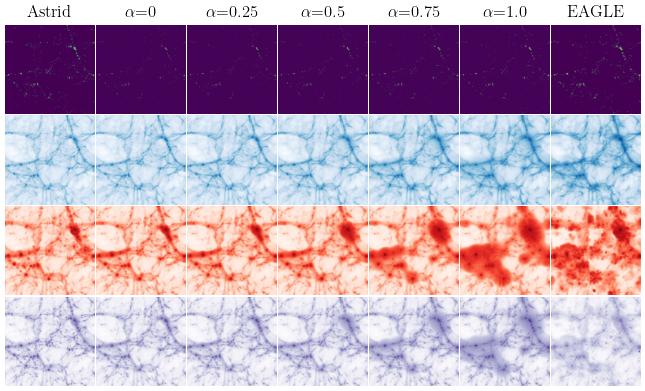

In [84]:
plt.figure(figsize=(8.2,4.7))
plt.subplots_adjust(wspace=0.02, hspace=0.01)
cls = ['viridis','Blues','Reds','Purples']

_, star_maps, gas_maps, T_maps, P_maps, _, _ = pipeline.loaded_datasets['Astrid']
plt.subplot(4,7,1)
plt.imshow(star_maps[astrid_idx],cmap='viridis')
plt.title(f'Astrid')
plt.axis('off')
plt.subplot(4,7,1+7)
plt.imshow(gas_maps[astrid_idx],cmap='Blues')
plt.axis('off')
plt.subplot(4,7,1+7*2)
plt.imshow(T_maps[astrid_idx],cmap='Reds')
plt.axis('off')
plt.subplot(4,7,1+7*3)
plt.imshow(P_maps[astrid_idx],cmap='Purples')
plt.axis('off')

_, star_maps, gas_maps, T_maps, P_maps, _, _ = pipeline.loaded_datasets['EAGLE']
plt.subplot(4,7,7)
plt.imshow(star_maps[eagle_idx],cmap='viridis')
plt.title(f'EAGLE')
plt.axis('off')
plt.subplot(4,7,7+7)
plt.imshow(gas_maps[eagle_idx],cmap='Blues')
plt.axis('off')
plt.subplot(4,7,7+7*2)
plt.imshow(T_maps[eagle_idx],cmap='Reds')
plt.axis('off')
plt.subplot(4,7,7+7*3)
plt.imshow(P_maps[eagle_idx],cmap='Purples')
plt.axis('off')

for i,res in enumerate(interpolation_results):
    for j,(channel,cl) in enumerate(zip(res['prediction'],cls)):
        plt.subplot(4,7,i+j*7+2)
        if j==0:
            plt.title(f'$\\alpha$={res['alpha']}')
            plt.axis('off')
        else:
            plt.axis('off')
        plt.imshow(channel,cmap=cl)
# plt.tight_layout()
plt.savefig('transform.png')
plt.show()


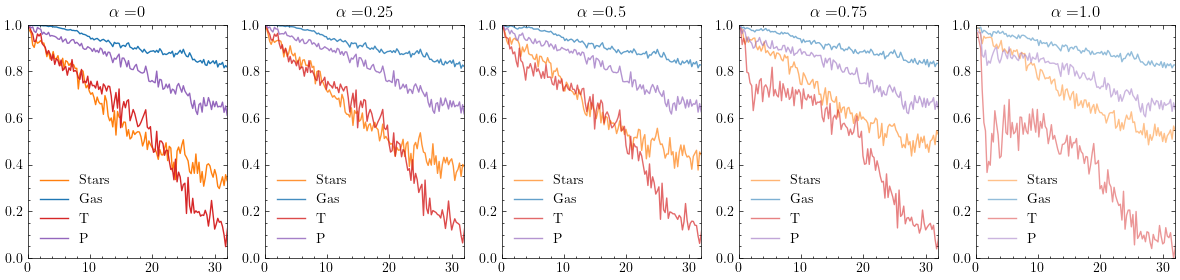

In [80]:
plt.figure(figsize=(12,3))

_, star_maps, gas_maps, T_maps, P_maps, _, _ = pipeline.loaded_datasets['Astrid']
real_astrid = (star_maps[astrid_idx],gas_maps[astrid_idx],T_maps[astrid_idx],P_maps[astrid_idx])

_, star_maps, gas_maps, T_maps, P_maps, _, _ = pipeline.loaded_datasets['EAGLE']
real_eagle = (star_maps[eagle_idx],gas_maps[eagle_idx],T_maps[eagle_idx],P_maps[eagle_idx])

channel_names = [('Stars','tab:orange'),('Gas','tab:blue'),('T','tab:red'),('P','tab:purple')]

for i, intp in enumerate(interpolation_results):
    plt.subplot(1,5,i+1)
    for pred, true, lbl in zip(intp['prediction'],real_astrid,channel_names):
        k,xcor = get_xcorr(pred,true)
        plt.plot(k,xcor,label=lbl[0],color=lbl[1],alpha=1.2**-i)

# for pred, true, lbl in zip(interpolation_results[-1]['prediction'],real_eagle,channel_names):
#     if lbl[0]=='Gas':
#         k,xcor = get_xcorr(pred,true)
#         plt.plot(k,xcor,label='EAGLE '+lbl[0],color=lbl[1],linestyle='--')
    plt.title(f'$\\alpha=${intp['alpha']}')
    plt.xlim(0,32)
    plt.ylim(0,1)
    plt.legend()
plt.tight_layout()
plt.show()

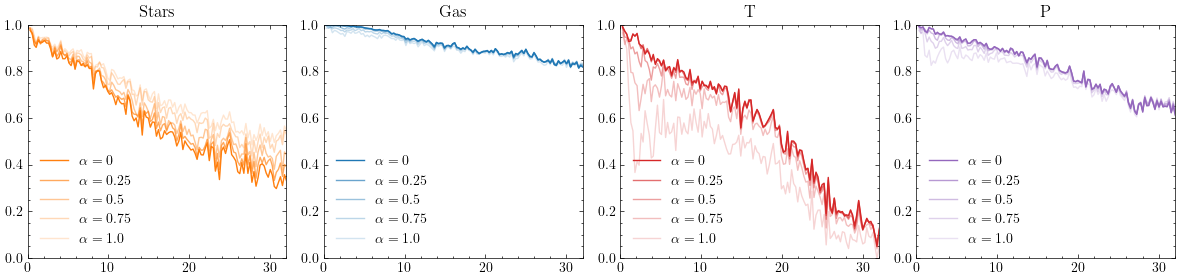

In [79]:
plt.figure(figsize=(12,3))

_, star_maps, gas_maps, T_maps, P_maps, _, _ = pipeline.loaded_datasets['Astrid']
real_astrid = (star_maps[astrid_idx],gas_maps[astrid_idx],T_maps[astrid_idx],P_maps[astrid_idx])

_, star_maps, gas_maps, T_maps, P_maps, _, _ = pipeline.loaded_datasets['EAGLE']
real_eagle = (star_maps[eagle_idx],gas_maps[eagle_idx],T_maps[eagle_idx],P_maps[eagle_idx])

channel_names = [('Stars','tab:orange'),('Gas','tab:blue'),('T','tab:red'),('P','tab:purple')]

for i, intp in enumerate(interpolation_results):
    
    for j,(pred, true_astrid,true_eagle, lbl) in enumerate(zip(intp['prediction'],real_astrid,real_eagle,channel_names)):
        plt.subplot(1,4,j+1)
        k,xcor = get_xcorr(pred,true_astrid)
        plt.plot(k,xcor,label=f'$\\alpha={intp['alpha']}$',color=lbl[1],alpha=1.5**-i)
        # k,xcor = get_xcorr(pred,true_eagle)
        # plt.plot(k,xcor,label=f'$\\alpha={intp['alpha']}$',color=lbl[1],alpha=1.5**-i)

# for pred, true, lbl in zip(interpolation_results[-1]['prediction'],real_eagle,channel_names):
#     if lbl[0]=='Gas':
#         k,xcor = get_xcorr(pred,true)
#         plt.plot(k,xcor,label='EAGLE '+lbl[0],color=lbl[1],linestyle='--')
        plt.legend()
        plt.title(lbl[0])
        plt.xlim(0,32)
        plt.ylim(0.0,1)
plt.tight_layout()
plt.savefig('corr_sample.png')
plt.show()

/tmp/ipykernel_3609156/1859095981.py:29: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,32)


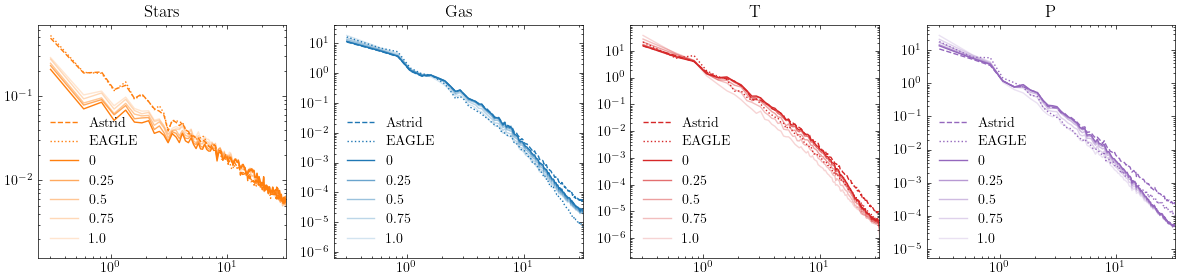

In [77]:
plt.figure(figsize=(12,3))

_, star_maps, gas_maps, T_maps, P_maps, _, _ = pipeline.loaded_datasets['Astrid']
real_astrid = (star_maps[astrid_idx],gas_maps[astrid_idx],T_maps[astrid_idx],P_maps[astrid_idx])

_, star_maps, gas_maps, T_maps, P_maps, _, _ = pipeline.loaded_datasets['EAGLE']
real_eagle = (star_maps[eagle_idx],gas_maps[eagle_idx],T_maps[eagle_idx],P_maps[eagle_idx])

channel_names = [('Stars','tab:orange'),('Gas','tab:blue'),('T','tab:red'),('P','tab:purple')]

for i, intp in enumerate(interpolation_results):
    
    for j,(pred, true_astrid,true_eagle, lbl) in enumerate(zip(intp['prediction'],real_astrid,real_eagle,channel_names)):
        plt.subplot(1,4,j+1)
        if i==0:
            k,pk = get_pk(true_astrid)
            plt.loglog(k,pk,label='Astrid',color=lbl[1],alpha=1,linestyle='--')
            k,pk = get_pk(true_eagle)
            plt.loglog(k,pk,label='EAGLE',color=lbl[1],alpha=1,linestyle=':')
        k,pk = get_pk(pred)
        plt.loglog(k,pk,label=intp['alpha'],color=lbl[1],alpha=1.5**-i)

# for pred, true, lbl in zip(interpolation_results[-1]['prediction'],real_eagle,channel_names):
#     if lbl[0]=='Gas':
#         k,xcor = get_xcorr(pred,true)
#         plt.plot(k,xcor,label='EAGLE '+lbl[0],color=lbl[1],linestyle='--')
        plt.legend()
        plt.title(lbl[0])
        plt.xlim(0,32)
plt.tight_layout()
plt.savefig('pk_sample.png')
plt.show()

In [85]:
# tSNE
all_labels_1P = pipeline.get_labels()
all_labels_LH = pipeline_LH.get_labels()
all_labels_resnet=np.append(all_labels_1P,all_labels_LH)

reducer = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, verbose=False)
embedding_tsne_indv = reducer.fit_transform(np.append(X_resnet_indv,X_resnet_LH,axis=0))

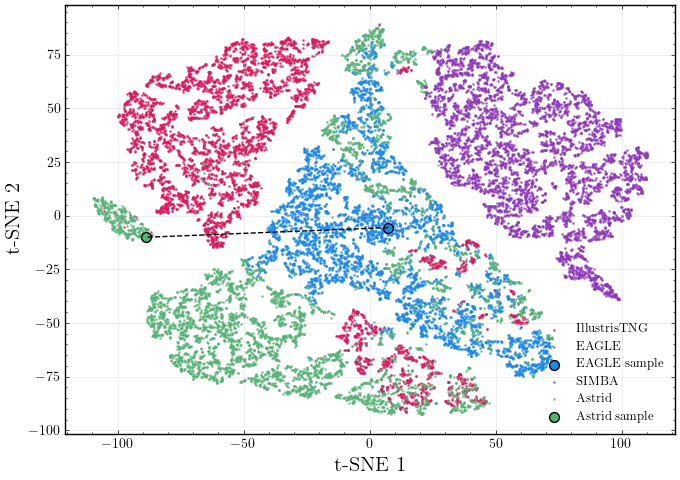

Visualization saved. Total samples: 21620


In [87]:
plt.figure(figsize=(7, 5))
colors = ['#D81B60','#1E88E5','#8F38BB','#57B375','#FFC107']
linex, liney = [],[]
# colors = ['#E74C3C', '#3498DB', '#27AE60', '#9B59B6', '#F39C12']

for i, model_name in enumerate(simulation_models):
    mask = [label == model_name for label in all_labels_resnet]
    plt.scatter(embedding_tsne_indv[mask, 0], embedding_tsne_indv[mask, 1], marker='x' if model_name=='Magneticum' else '.',
               c=colors[i], label='Magneticum (test)' if model_name=='Magneticum' else model_name, alpha=1 if model_name=='Magneticum' else 0.7, s=20 if model_name=='Magneticum' else 3)

    if model_name=='Astrid' or model_name=='EAGLE':
        idx=astrid_idx if model_name=='Astrid' else eagle_idx
        plt.scatter(embedding_tsne_indv[mask, 0][idx], embedding_tsne_indv[mask, 1][idx], marker='o',
                    c=colors[i],edgecolor='black', alpha=1, s=50, 
                    label='Astrid sample' if model_name=='Astrid' else 'EAGLE sample')
        linex.append(embedding_tsne_indv[mask, 0][idx])
        liney.append(embedding_tsne_indv[mask, 1][idx])

plt.plot(linex,liney,linestyle='--',c='black')
plt.xlabel('t-SNE 1',fontsize=15)
plt.ylabel('t-SNE 2',fontsize=15)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
# Make the frame thicker
for spine in plt.gca().spines.values():
    spine.set_linewidth(1)
plt.tight_layout()
plt.savefig("tsne_resnet_newnew.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization saved. Total samples: {len(embedding_tsne_indv)}")